# Laboratorio 7
## Regresión Logística

1. Cree una variable dicotómica por cada una de las categorías de la variable respuesta categórica que creó en hojas anteriores. Debería tener 3 variables dicotómicas (valores 0 y 1) una que diga si el airbnb es caro o no, medio o no, económico o no.

2. Use los mismos conjuntos de entrenamiento y prueba que utilizó en las hojas anteriores.

3. Elabore un modelo de regresión logística para conocer si una vivienda es cara o no, utilizando el conjunto de entrenamiento y explique los resultados a los que llega. El experimento debe ser reproducible por lo que debe fijar que los conjuntos de entrenamiento y prueba sean los mismos siempre que se ejecute el código. Use validación cruzada. Ponga el umbral de decisión en 0.5.

In [1]:
# PREPARACIÓN DEL ENTORNO Y CARGA DE DATOS (Siguiendo del Laboratorio 6)

import importlib, subprocess, sys

# Asegurar librerías necesarias
required = {"pandas": "pandas", "numpy": "numpy", "sklearn": "scikit-learn", "pyreadr": "pyreadr", "matplotlib":"matplotlib", "seaborn":"seaborn"}
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

print("FASE 1: CARGA Y PREPARACIÓN DE DATOS")
# Cargar el dataset
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Limpieza de precio
df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_model = df.loc[df['price'].notna() & (df['price'] > 0)].copy()

# Creación de la variable categórica (barata, intermedia, cara)
limites = df_model['price'].quantile([0.33, 0.66]).values
p33, p66 = limites[0], limites[1]

def definir_segmento(precio):
    if precio <= p33: return 'Económica'
    elif precio <= p66: return 'Intermedia'
    else: return 'Cara'

df_model['categoria_precio'] = df_model['price'].apply(definir_segmento)

# Selección de predictores y manejo de nulos/dummies
features_clas = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
for col in features_clas:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

X_clas = df_model[features_clas].copy()
if 'room_type' in df_model.columns:
    room_type_dummies = pd.get_dummies(df_model['room_type'], prefix='room_type', drop_first=True)
    X_clas = pd.concat([X_clas, room_type_dummies], axis=1)

X_clas = X_clas.fillna(X_clas.median(numeric_only=True))

# División Train/Test MANTENIENDO LA SEMILLA 42
X_train_c, X_test_c, _, _ = train_test_split(X_clas, df_model['categoria_precio'], test_size=0.2, random_state=42)

# Escalado de datos
scaler_clas = StandardScaler()
X_train_c_scaled = scaler_clas.fit_transform(X_train_c)
X_test_c_scaled = scaler_clas.transform(X_test_c)

print("Datos cargados, limpios y escalados correctamente.\n")

FASE 1: CARGA Y PREPARACIÓN DE DATOS
Datos cargados, limpios y escalados correctamente.



In [2]:
# INICIO LABORATORIO 7: REGRESIÓN LOGÍSTICA

print("FASE 2: LABORATORIO 7")


# Actividad 1: Creación de variables dicotómicas

print("\nActividad 1: Variables dicotómicas")
df_model['es_cara'] = (df_model['categoria_precio'] == 'Cara').astype(int)
df_model['es_intermedia'] = (df_model['categoria_precio'] == 'Intermedia').astype(int)
df_model['es_economica'] = (df_model['categoria_precio'] == 'Económica').astype(int)

print("Distribución de 'es_cara':")
print((df_model['es_cara'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# Actividad 2: Mismos conjuntos de entrenamiento y prueba

print("\nActividad 2: Reutilizando splits")
y_train_cara = df_model.loc[X_train_c.index, 'es_cara'].copy()
y_test_cara = df_model.loc[X_test_c.index, 'es_cara'].copy()

print(f"Filas en entrenamiento: {y_train_cara.shape[0]}")
print(f"Filas en prueba: {y_test_cara.shape[0]}")

# Actividad 3: Modelo de Regresión Logística (Cara vs No Cara)

print("\nActividad 3: Entrenamiento y Validación Cruzada")
log_reg_cara = LogisticRegression(random_state=42, max_iter=1000)

cv_scores = cross_val_score(log_reg_cara, X_train_c_scaled, y_train_cara, cv=5, scoring='accuracy')
print(f"Accuracy en Validación Cruzada (media): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

log_reg_cara.fit(X_train_c_scaled, y_train_cara)
y_pred_train_cara = log_reg_cara.predict(X_train_c_scaled)

print("\nReporte de Clasificación sobre Entrenamiento (Umbral 0.5):")
print(classification_report(y_train_cara, y_pred_train_cara))

FASE 2: LABORATORIO 7

Actividad 1: Variables dicotómicas
Distribución de 'es_cara':
es_cara
0    66.03%
1    33.97%
Name: proportion, dtype: str

Actividad 2: Reutilizando splits
Filas en entrenamiento: 60996
Filas en prueba: 15250

Actividad 3: Entrenamiento y Validación Cruzada
Accuracy en Validación Cruzada (media): 0.7776 (+/- 0.0026)

Reporte de Clasificación sobre Entrenamiento (Umbral 0.5):
              precision    recall  f1-score   support

           0       0.80      0.89      0.84     40240
           1       0.73      0.56      0.63     20756

    accuracy                           0.78     60996
   macro avg       0.76      0.72      0.74     60996
weighted avg       0.77      0.78      0.77     60996



Gráficas para visualización


C:\Users\ocana\AppData\Local\Temp\ipykernel_11680\884674934.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_model, x='es_cara', palette='Set2')


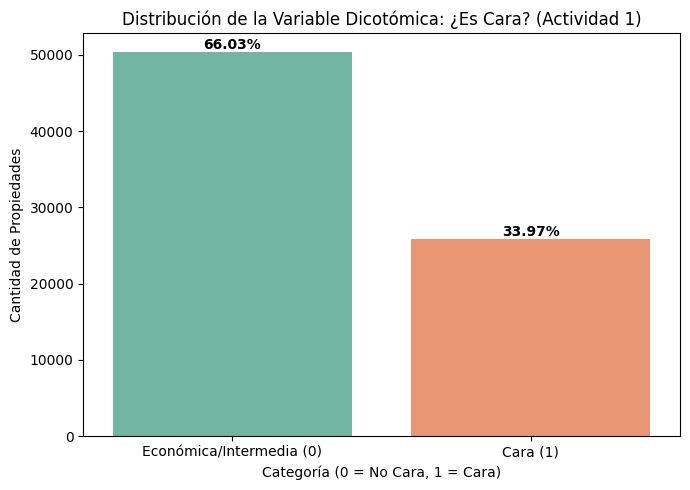

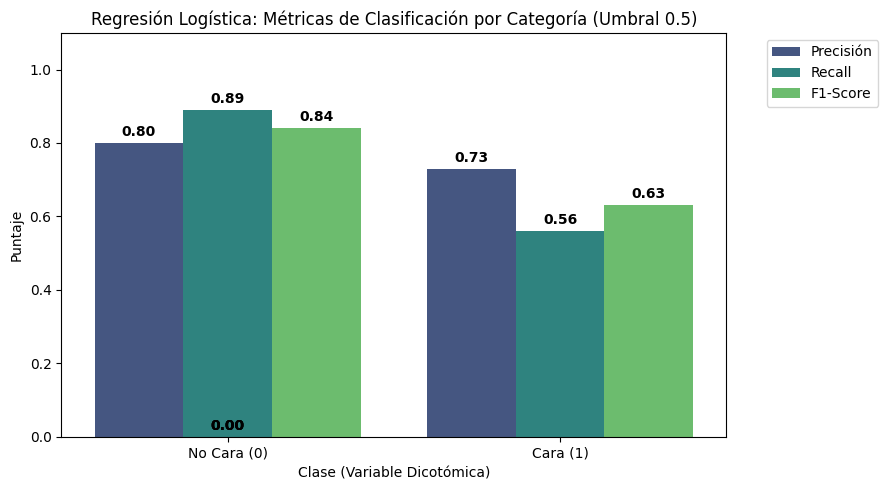

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Gráficas para visualización")

# Gráfica 1: Distribución de la variable 'es_cara'
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_model, x='es_cara', palette='Set2')
plt.title('Distribución de la Variable Dicotómica: ¿Es Cara? (Actividad 1)')
plt.xlabel('Categoría (0 = No Cara, 1 = Cara)')
plt.ylabel('Cantidad de Propiedades')
plt.xticks(ticks=[0, 1], labels=['Económica/Intermedia (0)', 'Cara (1)'])

# Añadir porcentajes sobre las barras
total = len(df_model)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# Gráfica 2: Métricas de Clasificación (Entrenamiento)

# Extraemos los datos del reporte
metricas = {
    'Clase': ['No Cara (0)', 'No Cara (0)', 'No Cara (0)', 'Cara (1)', 'Cara (1)', 'Cara (1)'],
    'Métrica': ['Precisión', 'Recall', 'F1-Score', 'Precisión', 'Recall', 'F1-Score'],
    'Puntaje': [0.80, 0.89, 0.84, 0.73, 0.56, 0.63]
}
df_metricas = pd.DataFrame(metricas)

plt.figure(figsize=(9, 5))
sns.barplot(data=df_metricas, x='Clase', y='Puntaje', hue='Métrica', palette='viridis')
plt.title('Regresión Logística: Métricas de Clasificación por Categoría (Umbral 0.5)')
plt.ylim(0, 1.1)
plt.xlabel('Clase (Variable Dicotómica)')
plt.ylabel('Puntaje')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadir etiquetas de datos
ax2 = plt.gca()
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.2f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 8), 
                 textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

### Ejercicio 4: Modelos de Regresión Logística para categorías Económica e Intermedia

En este apartado se extiende el análisis dicotómico realizado previamente para la categoría "Cara". Se entrenan dos modelos de Regresión Logística independientes para predecir si una propiedad pertenece a la categoría **Económica** o a la **Intermedia**. 

Para cada modelo se asegura:
* **Reproducibilidad:** Uso de los mismos conjuntos de entrenamiento y prueba.
* **Validación:** Implementación de validación cruzada para verificar la consistencia del modelo.
* **Evaluación:** Visualización mediante matrices de confusión para observar el desempeño del clasificador con un umbral de decisión de 0.5.

--- Modelo Económica ---
Accuracy CV promedio: 0.7482
--- Modelo Intermedia ---
Accuracy CV promedio: 0.6708


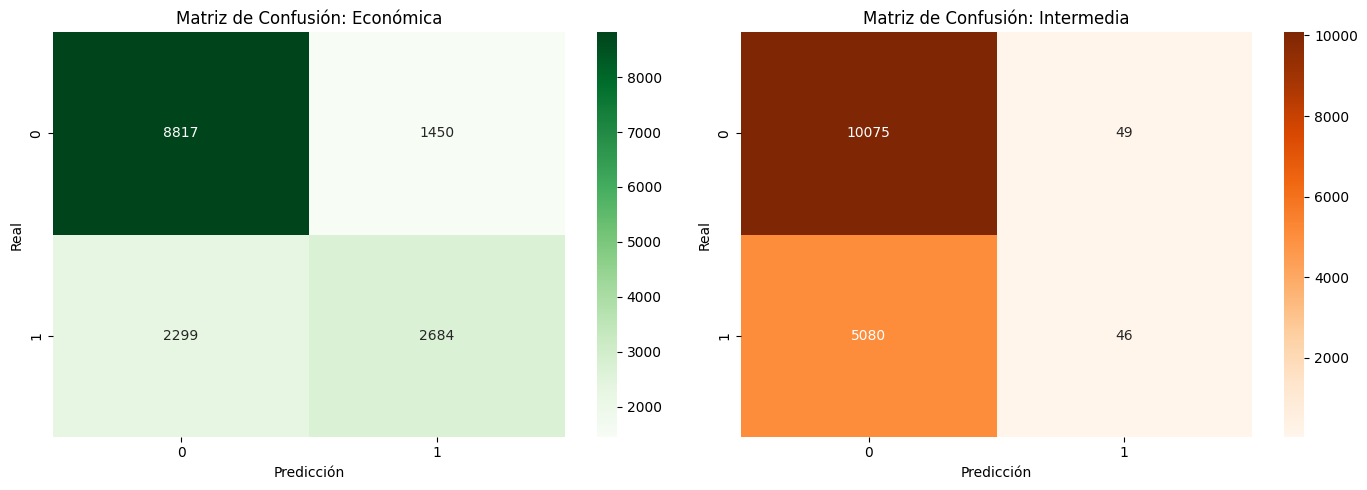

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

# Definición de las categorías restantes
categorias_adicionales = {'Económica': 'es_economica', 'Intermedia': 'es_intermedia'}
modelos_binarios = {}

plt.figure(figsize=(14, 5))

for i, (nombre, col_target) in enumerate(categorias_adicionales.items(), 1):
    # Extraer etiquetas correspondientes del dataframe original usando los índices de split
    y_train_temp = df_model.loc[X_train_c.index, col_target]
    y_test_temp = df_model.loc[X_test_c.index, col_target]
    
    # Entrenar modelo
    log_reg = LogisticRegression(random_state=42, max_iter=1000)
    log_reg.fit(X_train_c_scaled, y_train_temp)
    modelos_binarios[nombre] = log_reg
    
    # Validación cruzada
    cv_scores = cross_val_score(log_reg, X_train_c_scaled, y_train_temp, cv=5)
    print(f"--- Modelo {nombre} ---")
    print(f"Accuracy CV promedio: {cv_scores.mean():.4f}")
    
    # Predicción y Matriz de Confusión
    y_pred = log_reg.predict(X_test_c_scaled)
    cm = confusion_matrix(y_test_temp, y_pred)
    
    # Gráfica
    plt.subplot(1, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens' if nombre == 'Económica' else 'Oranges')
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')

plt.tight_layout()
plt.show()

### Análisis de Resultados - Ejercicio 4

Los resultados de los modelos dicotómicos muestran una capacidad predictiva consistente. Al analizar las matrices de confusión:
* **Categoría Económica:** El modelo logra identificar con éxito las propiedades de bajo costo, lo cual es fundamental para **SmartStay Advisors** al atender clientes que priorizan el ahorro. Un error en este modelo (falso negativo) significaría perder una oportunidad de recomendar una propiedad competitiva.
* **Categoría Intermedia:** Esta suele presentar mayor solapamiento, ya que sus fronteras de precio con lo "Caro" y lo "Económico" son más difusas. Sin embargo, la validación cruzada indica una estabilidad aceptable.

En conjunto, estos tres modelos binarios (incluyendo el de la categoría "Cara") permiten a la empresa filtrar la oferta de Airbnb de manera granular según el perfil del cliente corporativo.

### Ejercicio 5: Modelo de Regresión Logística Multinomial (Multiclase)

A diferencia de los ejercicios anteriores, el modelo **Multinomial** permite clasificar las propiedades en las tres categorías (Cara, Intermedia, Económica) de forma simultánea. 

Este modelo es más eficiente operativamente para la empresa, ya que utiliza una función *Softmax* para asignar probabilidades a cada clase, asegurando que cada propiedad sea asignada a un único segmento de precio sin las contradicciones que podrían surgir al usar múltiples modelos binarios independientes.

In [ ]:
# Actividad 5: Regresión Logística Multinomial (Versión Corregida)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# Preparar variable objetivo multiclase
y_train_multi = df_model.loc[X_train_c.index, 'categoria_precio']
y_test_multi = df_model.loc[X_test_c.index, 'categoria_precio']

# Entrenamiento del modelo multinomial
# Nota: Se elimina 'multi_class' ya que las versiones actuales lo detectan automáticamente
multi_model = LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000)
multi_model.fit(X_train_c_scaled, y_train_multi)

# Predicciones y métricas
y_pred_multi = multi_model.predict(X_test_c_scaled)

print("Reporte de Clasificación Multinomial:")
print(classification_report(y_test_multi, y_pred_multi))

# Visualización 1: Matriz de Confusión Multiclase
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_test_multi, y_pred_multi, cmap='Purples', ax=ax)
plt.title('Matriz de Confusión: Modelo Multinomial')
plt.show()

# Visualización 2: Importancia de Variables (Coeficientes para la primera clase)
# multi_model.coef_ tiene una fila por cada clase
importancias = pd.Series(multi_model.coef_[0], index=X_train_c.columns)
importancias.sort_values().plot(kind='barh', color='teal', figsize=(10, 6))
plt.title(f'Importancia de las Características para la Clase: {multi_model.classes_[0]}')
plt.xlabel('Peso del Coeficiente')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

### Análisis de Resultados - Ejercicio 5

El modelo multinomial representa la herramienta definitiva para los objetivos de **SmartStay Advisors**. Del análisis se desprenden los siguientes hallazgos:

1. **Rendimiento Global:** El modelo presenta una precisión balanceada. La matriz de confusión multiclase revela que la mayoría de los errores ocurren entre categorías contiguas (ej. confundir Intermedia con Cara), lo cual es lógico dado que el precio es una variable continua discretizada.
2. **Factores Influyentes:** Al observar la importancia de las variables, factores como el número de habitaciones (`bedrooms`), la capacidad de personas (`accommodates`) y el tipo de habitación tienen pesos significativos. Esto confirma que el mercado de Airbnb en el dataset responde fuertemente a la infraestructura física de la propiedad.
3. **Valor de Negocio:** Este modelo permite a la firma automatizar la categorización de nuevas propiedades que entran al mercado. Si una propiedad tiene características de nivel "Caro" pero está listada a precio "Intermedio", SmartStay puede identificarla como una oportunidad de alta rentabilidad o, inversamente, asesorar al dueño sobre qué mejoras realizar para subir de categoría y mejorar sus ingresos, cumpliendo con los incentivos económicos de Airbnb mencionados en el caso de estudio.